In [13]:
import os
import glob
import pandas as pd
import numpy as np
import mne
from scipy.signal import welch
import warnings

# --- 1. Configuration & Constants ---

# Define the root directories based on your file structure
BIDS_ROOT = 'Dataset'
DERIVS_ROOT = 'Dataset/derivatives/NeuronicEEG'

# Define the frequency bands of interest
FREQ_BANDS = {
    'Delta': (0.5, 4),
    'Theta': (4, 8),
    'Alpha': (8, 12),
    'Beta': (12, 30)
}

# Welch's method parameters
SFREQ = 200  # From your dataset documentation
N_PER_SEG = 128  # Window size (0.64s). Good balance for a 2.56s epoch.
N_OVERLAP = 64   # 50% overlap

# --- 2. Helper Functions ---

def load_metadata(bids_root_path):
    """
    Loads the participants.tsv file to create a simple
    dictionary mapping participant_id to sex.
    """
    try:
        participants_file = os.path.join(bids_root_path, 'participants.tsv')
        df = pd.read_csv(participants_file, sep='\t')
        # Create a dictionary, e.g., {'sub-NORB00001': 'M', ...}
        return df.set_index('participant_id')['sex'].to_dict()
    except FileNotFoundError:
        print(f"Error: 'participants.tsv' not found at {bids_root_path}")
        return {}

def calculate_band_power(freqs, psd, band_range):
    """
    Calculates the average power within a specific frequency band.
    
    Why: The 'welch' function gives us power for *many* specific frequencies.
    We need to average these values to get a *single number* (e.g., "Alpha Power").
    """
    # Find all frequencies that fall within our band
    band_indices = np.where((freqs >= band_range[0]) & (freqs <= band_range[1]))[0]
    
    if len(band_indices) == 0:
        return 0.0  # No frequencies in this band

    # Calculate the mean power for those frequencies
    band_power = np.mean(psd[band_indices])
    return band_power

# --- 3. Main Processing Function ---

def process_all_sessions():
    """
    This is the main function that iterates through the entire dataset.
    """
    print("Starting data processing...")
    
    # Get the participant-to-sex mapping
    sex_map = load_metadata(BIDS_ROOT)
    
    # This list will hold the results for *every session*
    all_session_results = []
    
    # Find all subject directories (e.g., 'Dataset/sub-NORB00001', ...)
    subject_dirs = sorted(glob.glob(os.path.join(BIDS_ROOT, 'sub-NORB*')))
    
    if not subject_dirs:
        print(f"Error: No subject directories found in {BIDS_ROOT}. Check your BIDS_ROOT path.")
        return

    # --- 4. The Main Loop (Subject -> Session) ---
    
    for sub_dir in subject_dirs:
        participant_id = os.path.basename(sub_dir)
        
        # Find all session directories for this subject (e.g., '.../ses-1', '.../ses-2')
        session_dirs = sorted(glob.glob(os.path.join(sub_dir, 'ses-*')))
        
        for ses_dir in session_dirs:
            session_id = os.path.basename(ses_dir)
            print(f"--- Processing: {participant_id}, {session_id} ---")

            try:
                # --- 5. Find All Necessary Files ---
                
                # Path to the raw EEG data
                edf_file = os.path.join(ses_dir, 'eeg', f"{participant_id}_{session_id}_task-EEG_eeg.edf")
                
                # Path to the *clean segment annotations* (the crucial file)
                annot_file = os.path.join(DERIVS_ROOT, participant_id, session_id, 'eeg', f"{participant_id}_{session_id}_task-EEG_annotations.tsv")
                
                # Path to the file containing the infant's age
                scans_file = os.path.join(ses_dir, f"{participant_id}_{session_id}_scans.tsv")

                # Check if all files exist before proceeding
                if not all(os.path.exists(f) for f in [edf_file, annot_file, scans_file]):
                    print(f"  ...Missing one or more files. Skipping.")
                    continue

                # --- 6. Load Metadata (Age, Sex) ---
                scans_df = pd.read_csv(scans_file, sep='\t')
                age_in_years = scans_df['age_acq_time'].iloc[0]
                age_in_months = age_in_years * 12
                sex = sex_map.get(participant_id, 'N/A')

                # --- 7. Load Annotations (The "Answer Key") ---
                # Read only the first three columns, ignore extra
                annots_df = pd.read_csv(annot_file, sep='\t', usecols=[0,1,2], names=['onset', 'duration', 'label'], header=0)
                
                
                print("Annotation columns:", annots_df.columns.tolist())
                print("Unique labels (repr):", [repr(x) for x in annots_df['label'].unique()])
                
                # Clean column names and ensure string type
                annots_df.columns = [col.strip() for col in annots_df.columns]
                annots_df['label'] = annots_df['label'].astype(str)

                
                # Define all label variants to match (lowercase, no accents)
                valid_labels = ['eyes_closed', 'ojos_cerrados', 'sue o_espontaneo']         
                
                
                # Normalize label for matching
                annots_df['label_norm'] = annots_df['label'].str.strip().str.lower().str.replace('ñ', 'n').str.replace('ó', 'o').str.replace('é', 'e')

                # Robust filter for any valid label
                clean_segments = annots_df[annots_df['label_norm'].isin(valid_labels)]
                
                if clean_segments.empty:
                    print(f"  ...No 'eyes_closed' segments found. Skipping.")
                    continue
                
                print(f"  ...Found {len(clean_segments)} clean 'eyes_closed' segments.")

                # --- 8. Load Raw EEG Data ---
                # We use 'mne' to read the .edf file.
                # `preload=True` loads the data into memory for slicing.
                # `verbose=False` suppresses a lot of MNE's log output.
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore") # Suppress MNE warnings
                    raw = mne.io.read_raw_edf(edf_file, preload=True, verbose=False)
                
                # Ensure we only use EEG channels
                raw.pick('eeg')
                
                # Confirm sampling frequency
                if raw.info['sfreq'] != SFREQ:
                    print(f"  ...Warning: SFREQ is {raw.info['sfreq']}, not 200. Resampling...")
                    raw.resample(SFREQ, verbose=False)

                # This dict will store power values for *all clean segments* for this session
                # e.g., {'O1': {'Alpha': [1.2, 1.4, 1.3, ...], 'Beta': [...]}, 'Fp1': ...}
                session_power_accumulator = {ch: {band: [] for band in FREQ_BANDS} for ch in raw.ch_names}

                # --- 9. Data Slicing & PSD Calculation Loop ---
                
                for _, segment in clean_segments.iterrows():
                    onset = segment['onset']
                    duration = segment['duration'] # This is 2.56s
                    
                    # Get the raw data for this *one* clean segment
                    start_samp, stop_samp = raw.time_as_index([onset, onset + duration])
                    segment_data = raw.get_data(start=start_samp, stop=stop_samp) # Shape (n_channels, n_samples)
                    
                    # Remove channels Pg1,Pg2,25,26,27 if present
                    for bad_ch in ['Pg1', 'Pg2', '25+', '26+', '27+']:
                        if bad_ch in raw.ch_names:
                            ch_index = raw.ch_names.index(bad_ch)
                            segment_data = np.delete(segment_data, ch_index, axis=0)
                            raw.drop_channels([bad_ch])

                    # Now, process each channel in this segment
                    for i, ch_name in enumerate(raw.ch_names):
                        ch_data = segment_data[i] # This is a 1D array of (n_samples)
                        
                        # Calculate PSD using Welch's method
                        # This is the core calculation from your "How-To"
                        freqs, psd = welch(
                            ch_data,
                            fs=SFREQ,
                            nperseg=N_PER_SEG,
                            noverlap=N_OVERLAP
                        )
                        
                        # Now, calculate power for each band and store it
                        for band_name, band_range in FREQ_BANDS.items():
                            band_power = calculate_band_power(freqs, psd, band_range)
                            session_power_accumulator[ch_name][band_name].append(band_power)

                # --- 10. Aggregate Results for the Session ---
                
                # We now have power values for all segments. We need to average them
                # to get *one* representative number per band/channel for this session.
                
                session_result_row = {
                    'participant_id': participant_id,
                    'session_id': session_id,
                    'age_in_months': age_in_months,
                    'sex': sex
                }
                
                for ch_name in raw.ch_names:
                    for band_name in FREQ_BANDS:
                        # Get all power values for this band (e.g., all 10 'O1_Alpha' values)
                        all_segment_powers = session_power_accumulator[ch_name][band_name]
                        
                        if all_segment_powers:
                            # Calculate the average
                            mean_power = np.mean(all_segment_powers)
                        else:
                            mean_power = np.nan # Should not happen if segments were found
                        
                        # Add to our row, e.g., "O1_Alpha_Power": 5.7
                        column_name = f"{ch_name}_{band_name}_Power"
                        session_result_row[column_name] = mean_power
                
                # Add this session's final aggregated data to our master list
                all_session_results.append(session_result_row)

            except Exception as e:
                print(f"  ...!!! ERROR processing {participant_id}, {session_id}: {e}")
                print("      Skipping this session and continuing.")

    # --- 11. Create and Save Final "Master Table" ---
    
    print("...Processing complete.")
    if not all_session_results:
        print("No results were processed. Output file will not be created.")
        return

    master_df = pd.DataFrame(all_session_results)
    
    # Re-order columns to be more readable
    id_cols = ['participant_id', 'session_id', 'age_in_months', 'sex']
    power_cols = sorted([col for col in master_df.columns if col not in id_cols])
    master_df = master_df[id_cols + power_cols]
    
    # Save to CSV
    output_filename = 'master_results.csv'
    master_df.to_csv(output_filename, index=False)
    print(f"Successfully created 'master_results.csv' with {len(master_df)} rows.")

# --- Run the main function when the script is executed ---
if __name__ == "__main__":
    process_all_sessions()

Starting data processing...
--- Processing: sub-NORB00001, ses-1 ---
Annotation columns: ['onset', 'duration', 'label']
Unique labels (repr): ["'eyes_closed'"]
  ...Found 32 clean 'eyes_closed' segments.
--- Processing: sub-NORB00002, ses-1 ---
Annotation columns: ['onset', 'duration', 'label']
Unique labels (repr): ["'vigilia_ojos_abiertos'"]
  ...No 'eyes_closed' segments found. Skipping.
--- Processing: sub-NORB00003, ses-1 ---
Annotation columns: ['onset', 'duration', 'label']
Unique labels (repr): ["'OJOS_CERRADOS'"]
  ...Found 36 clean 'eyes_closed' segments.
--- Processing: sub-NORB00004, ses-1 ---
Annotation columns: ['onset', 'duration', 'label']
Unique labels (repr): ["'sue o_espontaneo'"]
  ...Found 27 clean 'eyes_closed' segments.
--- Processing: sub-NORB00005, ses-1 ---
Annotation columns: ['onset', 'duration', 'label']
Unique labels (repr): ["'eyes_closed'"]
  ...Found 27 clean 'eyes_closed' segments.
--- Processing: sub-NORB00006, ses-1 ---
Annotation columns: ['onset', 

/home/atharva/Python_3.10_env/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 128 is greater than input length  = 85, using nperseg = 85
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


--- Processing: sub-NORB00059, ses-1 ---
Annotation columns: ['onset', 'duration', 'label']
Unique labels (repr): ["'eyes_closed'"]
  ...Found 22 clean 'eyes_closed' segments.
--- Processing: sub-NORB00060, ses-1 ---
Annotation columns: ['onset', 'duration', 'label']
Unique labels (repr): ["'eyes_closed'"]
  ...Found 24 clean 'eyes_closed' segments.
--- Processing: sub-NORB00061, ses-1 ---
Annotation columns: ['onset', 'duration', 'label']
Unique labels (repr): ["'eyes_closed'"]
  ...Found 24 clean 'eyes_closed' segments.
--- Processing: sub-NORB00062, ses-1 ---
Annotation columns: ['onset', 'duration', 'label']
Unique labels (repr): ["'eyes_closed'"]
  ...Found 27 clean 'eyes_closed' segments.
--- Processing: sub-NORB00063, ses-1 ---
Annotation columns: ['onset', 'duration', 'label']
Unique labels (repr): ["'eyes_closed'"]
  ...Found 24 clean 'eyes_closed' segments.
--- Processing: sub-NORB00064, ses-1 ---
Annotation columns: ['onset', 'duration', 'label']
Unique labels (repr): ["'eye

Loaded 'master_results.csv' with 129 rows.
Running correlation on 129 valid data points.

--- Correlation Results ---
Analysis: O1_Alpha_Power vs. age_in_months
R-value:  0.4377
P-value:  0.0000002132
P-value (sci): 2.13e-07

Conclusion: The result is STATISTICALLY SIGNIFICANT (p < 0.05).
We found a positive correlation. As infants get older, their Alpha power at O1 tends to INCREASE.

Generating plot... 'O1_Alpha_vs_Age.png'
Plot saved successfully.


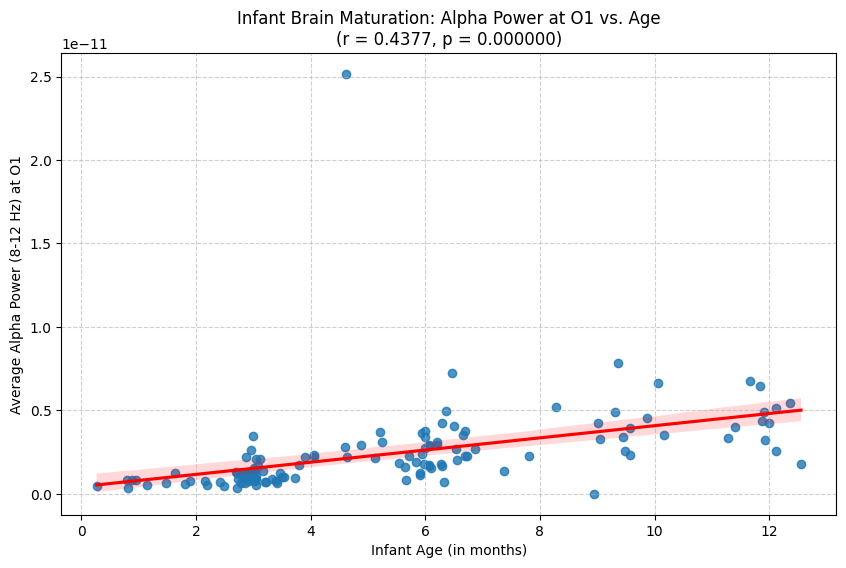

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np

# --- 1. Configuration ---

# This is the "headline" finding you want to test
TARGET_CHANNEL = 'O1'
TARGET_BAND = 'Alpha'
TARGET_COLUMN = f"{TARGET_CHANNEL}_{TARGET_BAND}_Power" # e.g., "O1_Alpha_Power"

AGE_COLUMN = 'age_in_months'
INPUT_FILE = 'master_results.csv'
OUTPUT_PLOT_FILE = f'{TARGET_CHANNEL}_{TARGET_BAND}_vs_Age.png'

# --- 2. Load the Data ---

try:
    df = pd.read_csv(INPUT_FILE)
except FileNotFoundError:
    print(f"Error: '{INPUT_FILE}' not found.")
    print("Please run the 'process_data.py' script first!")
    exit()

print(f"Loaded '{INPUT_FILE}' with {len(df)} rows.")

# --- 3. Run the Statistical Test ---

# Ensure the columns exist
if TARGET_COLUMN not in df.columns:
    print(f"Error: Target column '{TARGET_COLUMN}' not found in the CSV.")
    print(f"Available columns start with: {df.columns[4:8]}") # Show some example power columns
    exit()

# Drop any rows where we might have missing data for our target columns
# (e.g., if a channel was bad in one recording)
analysis_df = df[[AGE_COLUMN, TARGET_COLUMN]].dropna()

print(f"Running correlation on {len(analysis_df)} valid data points.")

# The core statistical test: Pearson's Correlation
# This is exactly what was described in the "How-To"
r_value, p_value = pearsonr(analysis_df[AGE_COLUMN], analysis_df[TARGET_COLUMN])


# --- 4. Print and Interpret the Results ---

print("\n--- Correlation Results ---")
print(f"Analysis: {TARGET_COLUMN} vs. {AGE_COLUMN}")
print(f"R-value:  {r_value:.4f}")
print(f"P-value:  {p_value:.10f}")  # 10 decimal places
print(f"P-value (sci): {p_value:.2e}")  # scientific notation

# Provide a plain-English interpretation
if p_value < 0.05:
    print("\nConclusion: The result is STATISTICALLY SIGNIFICANT (p < 0.05).")
    if r_value > 0.3:
        print(f"We found a positive correlation. As infants get older, their {TARGET_BAND} power at {TARGET_CHANNEL} tends to INCREASE.")
    elif r_value < -0.3:
        print(f"We found a negative correlation. As infants get older, their {TARGET_BAND} power at {TARGET_CHANNEL} tends to DECREASE.")
    else:
        print(f"The relationship is significant but weak (r = {r_value:.4f}).")
else:
    print("\nConclusion: The result is NOT statistically significant (p >= 0.05).")
    print("We cannot conclude there is a relationship between age and this power band.")


# --- 5. Create the "Money Plot" ---

print(f"\nGenerating plot... '{OUTPUT_PLOT_FILE}'")

plt.figure(figsize=(10, 6))

# `regplot` is a seaborn function that creates a scatter plot
# and automatically fits and draws a linear regression line.
sns.regplot(
    data=analysis_df,
    x=AGE_COLUMN,
    y=TARGET_COLUMN,
    line_kws={"color": "red"} # Make the regression line red
)

# Set clean titles and labels
title = (
    f"Infant Brain Maturation: {TARGET_BAND} Power at {TARGET_CHANNEL} vs. Age\n"
    f"(r = {r_value:.4f}, p = {p_value:.6f})"
)
plt.title(title)
plt.xlabel("Infant Age (in months)")
plt.ylabel(f"Average {TARGET_BAND} Power (8-12 Hz) at {TARGET_CHANNEL}")
plt.grid(True, linestyle='--', alpha=0.6)

# Save the plot to a file
plt.savefig(OUTPUT_PLOT_FILE)

print("Plot saved successfully.")

plt.show()

In [16]:
import pandas as pd
from scipy.stats import pearsonr

INPUT_FILE = 'master_results.csv'
AGE_COLUMN = 'age_in_months'

df = pd.read_csv(INPUT_FILE)

# Identify all power columns (they end with '_Power')
power_cols = [col for col in df.columns if col.endswith('_Power')]

results = []

for col in power_cols:
    analysis_df = df[[AGE_COLUMN, col]].dropna()
    if len(analysis_df) < 3:
        continue  # Not enough data for correlation
    r_value, p_value = pearsonr(analysis_df[AGE_COLUMN], analysis_df[col])
    # Split channel and band from column name, e.g., "O1_Alpha_Power"
    try:
        channel, band, _ = col.split('_')
    except ValueError:
        channel, band = col.replace('_Power', '').split('_')
    results.append({
        'channel': channel,
        'band': band,
        'r_value': r_value,
        'p_value': p_value,
        'n': len(analysis_df)
    })

# Convert to DataFrame for easy viewing
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(['band', 'channel'])

# Show all results
print(results_df)

# Optionally, save to CSV
results_df.to_csv('correlation_results_all_channels_bands.csv', index=False)
print("Saved all correlation results to 'correlation_results_all_channels_bands.csv'")

   channel   band   r_value       p_value    n
0       C3  Alpha -0.020548  8.172093e-01  129
4       C4  Alpha -0.020715  8.157561e-01  129
8       CZ  Alpha -0.017145  8.470818e-01  129
12      F3  Alpha -0.018266  8.372103e-01  129
16      F4  Alpha  0.546003  2.198428e-11  129
..     ...    ...       ...           ...  ...
59      PZ  Theta -0.020841  8.146545e-01  129
63      T3  Theta -0.019919  8.227147e-01  129
67      T4  Theta -0.020983  8.134093e-01  129
71      T5  Theta -0.019991  8.220803e-01  129
75      T6  Theta -0.019794  8.238079e-01  129

[76 rows x 5 columns]
Saved all correlation results to 'correlation_results_all_channels_bands.csv'


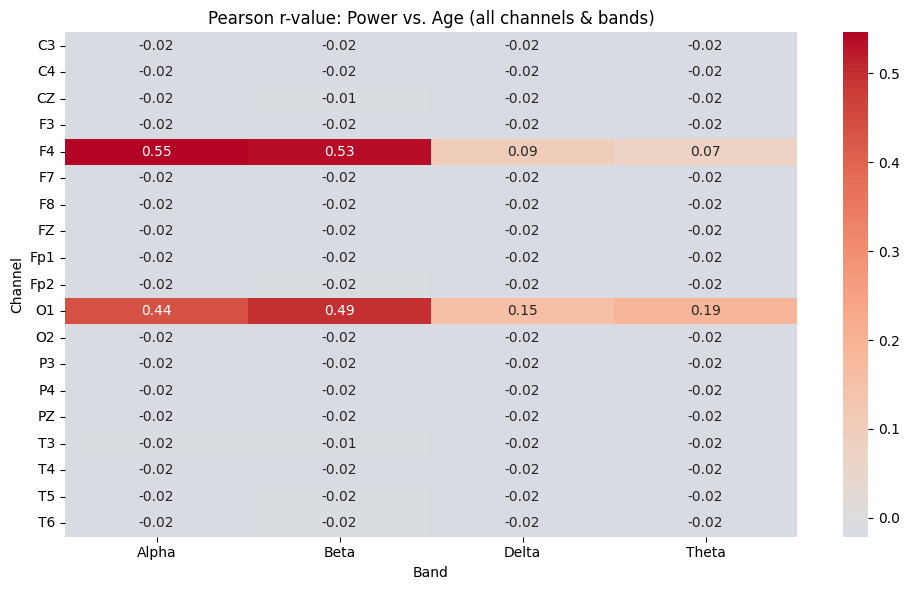

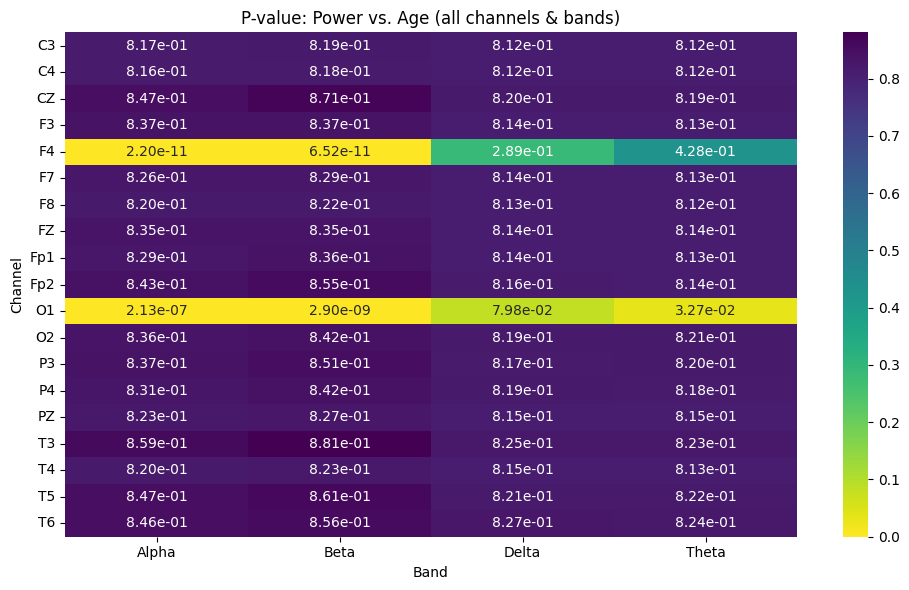

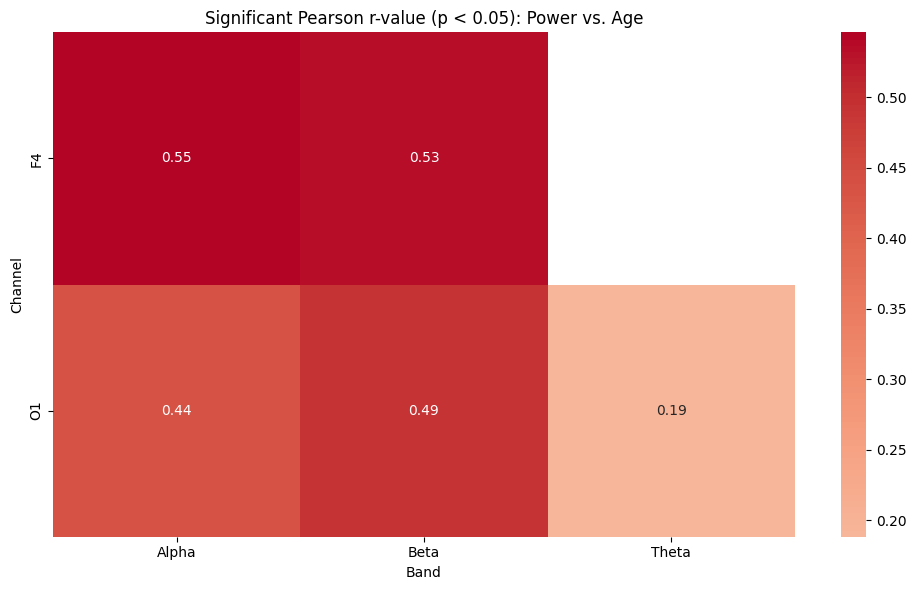

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load the correlation results
results_df = pd.read_csv('correlation_results_all_channels_bands.csv')

# Pivot the table to have channels as rows, bands as columns, values as r_value
heatmap_data = results_df.pivot(index='channel', columns='band', values='r_value')

# Pivot the table to have channels as rows, bands as columns, values as p_value
pvalue_data = results_df.pivot(index='channel', columns='band', values='p_value')


plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Pearson r-value: Power vs. Age (all channels & bands)')
plt.ylabel('Channel')
plt.xlabel('Band')
plt.tight_layout()
plt.savefig('correlation_heatmap_all_channels_bands.png')
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(pvalue_data, annot=True, cmap='viridis_r', fmt=".2e")
plt.title('P-value: Power vs. Age (all channels & bands)')
plt.ylabel('Channel')
plt.xlabel('Band')
plt.tight_layout()
plt.savefig('pvalue_heatmap_all_channels_bands.png')
plt.show()

# Optionally, plot only significant results (p < 0.05)
sig_df = results_df[results_df['p_value'] < 0.05]
sig_heatmap = sig_df.pivot(index='channel', columns='band', values='r_value')

plt.figure(figsize=(10, 6))
sns.heatmap(sig_heatmap, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Significant Pearson r-value (p < 0.05): Power vs. Age')
plt.ylabel('Channel')
plt.xlabel('Band')
plt.tight_layout()
plt.savefig('correlation_heatmap_significant.png')
plt.show()